Load Data - temperature and precipitation graph of data used for feature importance and predictive model returns erroneous january values compared to any meteorogical site. 

In [16]:
import pandas as pd

# Load the dataframe from CSV
df = pd.read_csv(r"..\..\data\cleaned_data_w_class.csv")

filtered_df = df[df["caffeine_class"] != "Absent"]

# Extract the first 36 columns
df_extracted = filtered_df.iloc[:, :36]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation

Load Data - Validating if January data produces same anomally thoughout the raster

In [17]:
#df = pd.read_csv(r"..\..\data\coll_tree_node.csv")
df = pd.read_csv(r"..\..\data\coll_all.csv")
# filtered_df = df[df['caffeine_class'] != "Absent"]
filtered_df = df.copy()

# Extract the first 36 columns
df_extracted = filtered_df.iloc[:, 8:44]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation


# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

min_temps.describe()

,clim_1_tmin1_Monthly minimum temperature - January (°C x 10),clim_2_tmin2_Monthly minimum temperature - February (°C x 10),clim_3_tmin3_Monthly minimum temperature - March (°C x 10),clim_4_tmin4_Monthly minimum temperature - April (°C x 10),clim_5_tmin5_Monthly minimum temperature - May (°C x 10),clim_6_tmin6_Monthly minimum temperature - June (°C x 10),clim_7_tmin7_Monthly minimum temperature - July (°C x 10),clim_8_tmin8_Monthly minimum temperature - August (°C x 10),clim_9_tmin9_Monthly minimum temperature - September (°C x 10),clim_10_tmin10_Monthly minimum temperature - October (°C x 10),clim_11_tmin11_Monthly minimum temperature - November (°C x 10),clim_12_tmin12_Monthly minimum temperature - December (°C x 10)
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,167.081877,201.067157,196.766329,185.890524,161.644894,143.903404,139.622815,142.298988,151.413063,184.272309,194.661454,200.999080
std,33.810213,27.787044,28.440702,31.726443,34.845501,35.256269,34.522517,34.404696,34.558376,31.364156,29.136710,27.363911
min,63.000000,102.000000,102.000000,92.000000,62.000000,44.000000,42.000000,40.000000,51.000000,79.000000,94.000000,104.000000
25%,132.000000,174.000000,166.000000,153.000000,126.000000,107.000000,105.000000,107.000000,116.000000,152.000000,166.000000,174.000000
50%,176.000000,213.000000,209.000000,193.000000,164.000000,149.000000,144.000000,147.000000,157.000000,194.000000,206.000000,214.000000
75%,197.000000,224.000000,220.000000,212.000000,188.500000,170.000000,168.000000,170.000000,180.000000,211.000000,217.000000,223.000000
max,224.000000,242.000000,242.000000,241.000000,234.000000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


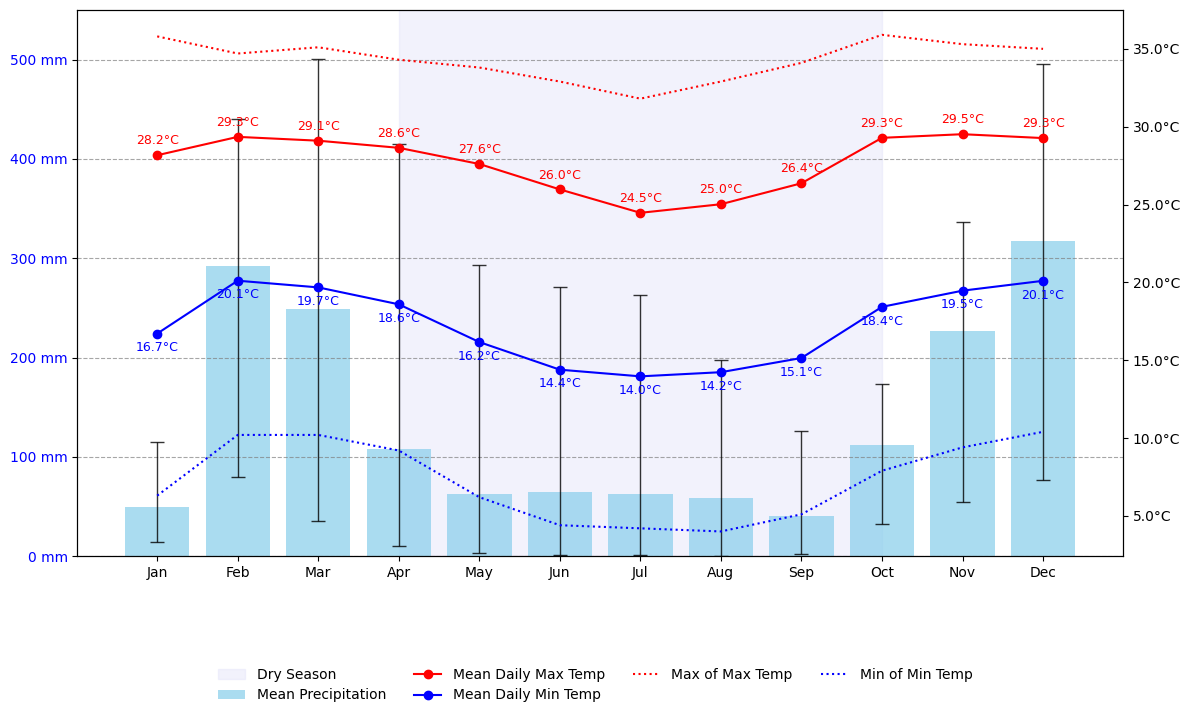

: 

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Calculate monthly statistics
mean_min_temps = min_temps.mean() / 10
mean_max_temps = max_temps.mean() / 10
min_monthly_min_temps = min_temps.min() / 10
max_monthly_max_temps = max_temps.max() / 10
mean_precip = precip.mean()

min_precip = precip.min()
max_precip = precip.max()

# Define months for x-axis
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Formatter functions
def mm_formatter(x, pos):
    return f"{x:.0f} mm"

def c_formatter(x, pos):
    return f"{x:.1f}°C"

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Highlight dry season
ax1.axvspan(3, 9, color="lavender", alpha=0.5, label="Dry Season")
ax1.grid(axis="y", linestyle="--", alpha=0.7, color="gray")

# Plot precipitation bars with ranges
lower_deviation = mean_precip - min_precip
upper_deviation = max_precip - mean_precip
bars = ax1.bar(
    months,
    mean_precip,
    yerr=[lower_deviation, upper_deviation],
    color="skyblue",
    alpha=0.7,
    label="Mean Precipitation",
    capsize=5,
    error_kw={"elinewidth": 1, "alpha": 0.8},
)
ax1.set_ylim(0, 550)
#ax1.set_ylabel("Precipitation (mm)", color="blue")
ax1.yaxis.set_major_formatter(FuncFormatter(mm_formatter))
ax1.tick_params(axis="y", labelcolor="blue")

# Create twin axis for temperature
ax2 = ax1.twinx()

# Plot mean daily temperatures
ax2.plot(months, mean_max_temps, color="red", linestyle="-", marker="o", label="Mean Daily Max Temp")
ax2.plot(months, mean_min_temps, color="blue", linestyle="-", marker="o", label="Mean Daily Min Temp")

# Plot min of min temps and max of max temps (dotted lines)
ax2.plot(months, max_monthly_max_temps, color="red", linestyle="dotted", label="Max of Max Temp")
ax2.plot(months, min_monthly_min_temps, color="blue", linestyle="dotted", label="Min of Min Temp")

# Annotate temperature lines with values
for i, (min_temp, max_temp) in enumerate(zip(mean_min_temps, mean_max_temps)):
    # Annotate max temp (red) with an offset
    ax2.text(
        i,
        max_temp + 0.5,
        f"{max_temp:.1f}°C",
        color="red",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    # Annotate min temp (blue) with an offset
    ax2.text(
        i,
        min_temp - 0.5,
        f"{min_temp:.1f}°C",
        color="blue",
        ha="center",
        va="top",
        fontsize=9,
    )

#ax2.set_ylabel("Temperature (°C)", color="black")
ax2.yaxis.set_major_formatter(FuncFormatter(c_formatter))
ax2.tick_params(axis="y", labelcolor="black")

# Add legends
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


NameError: name 'precip_error' is not defined

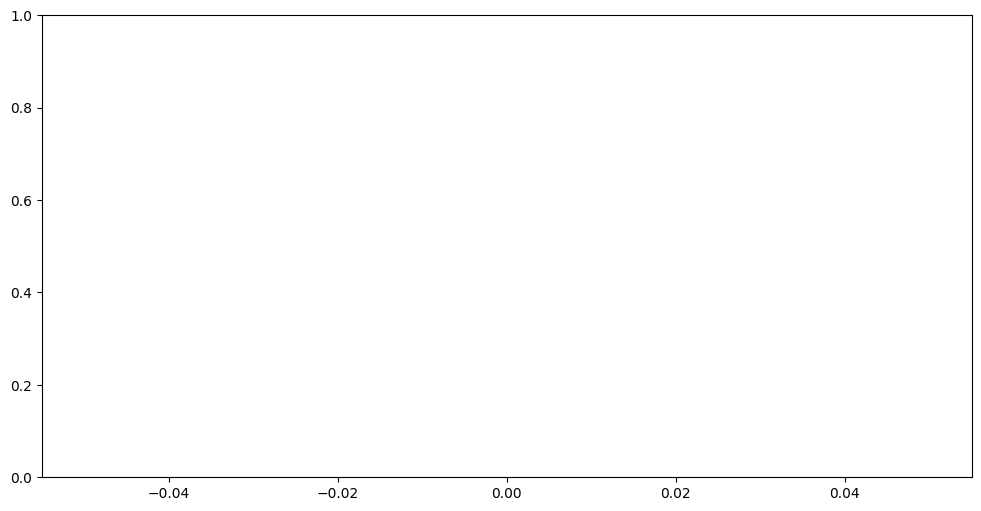

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Define the dry season months (e.g., May to October)
dry_season_months = ["May", "Jun", "Jul", "Aug", "Sep", "Oct"]
# Map months to indices
month_indices = {
    month: i
    for i, month in enumerate(
        [
            "Jan",
            "Feb",
            "Mar",
            "Apr",
            "May",
            "Jun",
            "Jul",
            "Aug",
            "Sep",
            "Oct",
            "Nov",
            "Dec",
        ]
    )
}

# Create the figure and first axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Highlight the dry season with a shaded region (from May to Oct)
ax1.axvspan(
    month_indices["May"] - 0.5,
    month_indices["Oct"] + 0.5,
    color="lightyellow",
    alpha=0.5,
    label="Dry Season",
)

# Plot precipitation bars with error bars
bars = ax1.bar(
    months,
    mean_precip,
    yerr=precip_error,
    color="skyblue",
    alpha=0.7,
    label="Mean Precipitation",
    capsize=5,
    error_kw={"elinewidth": 1, "alpha": 0.8},
)

# Remove y-axis label and set tick formatter
ax1.yaxis.set_major_formatter(FuncFormatter(mm_formatter))
ax1.tick_params(axis="y", labelcolor="blue")

# Create a twin axis for temperature
ax2 = ax1.twinx()

# Plot the mean daily maximum temperature (line)
ax2.plot(
    months,
    mean_max_temps,
    color="red",
    linestyle="-",
    marker="o",
    label="Mean Daily Max Temp",
)

# Plot the maximum daily temperature (red dotted line)
ax2.plot(
    months,
    max_monthly_max_temps,
    color="red",
    linestyle="dotted",
    label="Max of Max Temp",
)

# Plot the mean daily minimum temperature (line)
ax2.plot(
    months,
    mean_min_temps,
    color="blue",
    linestyle="-",
    marker="o",
    label="Mean Daily Min Temp",
)

# Plot the minimum daily temperature (blue dotted line)
ax2.plot(
    months,
    min_monthly_min_temps,
    color="blue",
    linestyle="dotted",
    label="Min of Min Temp",
)

# Annotate the temperature lines with the values
for i, (min_temp, max_temp) in enumerate(zip(mean_min_temps, mean_max_temps)):
    # Annotate max temp (red) with an offset to prevent overlap
    ax2.text(
        i,
        max_temp + 1,
        f"{max_temp:.1f}°C",
        color="red",
        ha="center",
        va="bottom",
        fontsize=9,
    )

    # Annotate min temp (blue) with an offset to prevent overlap
    ax2.text(
        i,
        min_temp - 1,
        f"{min_temp:.1f}°C",
        color="blue",
        ha="center",
        va="top",
        fontsize=9,
    )

# Remove y-axis label and set tick formatter
ax2.yaxis.set_major_formatter(FuncFormatter(c_formatter))
ax2.tick_params(axis="y", labelcolor="black")

# Add a title and grid
# plt.title('Monthly Temperature and Precipitation with Temperature Extremes')
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Add legends at the bottom
fig.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=10
)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [34]:
df = pd.read_csv(r"..\..\data\cleaned_data_num_w_class.csv")

# filtered_df = df[df['caffeine_class'] != "Absent"]
filtered_df = df.copy()

# Extract the first 36 columns
df_extracted = filtered_df.iloc[:, :36]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation


# coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
# coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

min_temps.describe()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,clim_11_tmin11_nov,clim_12_tmin12_dec
count,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,179.804183,212.990494,208.714829,197.885932,174.030418,156.652091,152.368821,155.047529,164.307985,196.355513,206.861217,212.853612
std,25.490870,19.901709,20.663343,24.803424,29.937380,30.523662,29.863258,28.283322,26.873889,22.953971,21.029180,19.433487
min,103.000000,143.000000,143.000000,135.000000,113.000000,90.000000,88.000000,89.000000,89.000000,122.000000,136.000000,146.000000
25%,167.000000,207.000000,200.500000,186.000000,161.000000,144.000000,140.000000,144.000000,153.250000,185.000000,200.000000,208.250000
50%,184.000000,220.000000,216.000000,205.000000,177.000000,157.000000,154.000000,162.000000,169.000000,201.000000,214.000000,219.000000
75%,200.000000,226.000000,222.000000,215.750000,194.000000,177.000000,174.000000,173.000000,182.000000,211.750000,219.000000,225.000000
max,224.000000,242.000000,242.000000,241.000000,234.000000,219.000000,209.000000,208.000000,213.000000,236.000000,242.000000,242.000000


In [44]:
precip.describe()

,clim_25_prec1_Monthly total precipitation - January (mm.month-1),clim_26_prec2_Monthly total precipitation - February (mm.month-1),clim_27_prec3_Monthly total precipitation - March (mm.month-1),clim_28_prec4_Monthly total precipitation - April (mm.month-1),clim_29_prec5_Monthly total precipitation - May (mm.month-1),clim_30_prec6_Monthly total precipitation - June (mm.month-1),clim_31_prec7_Monthly total precipitation - July (mm.month-1),clim_32_prec8_Monthly total precipitation - August (mm.month-1),clim_33_prec9_Monthly total precipitation - September (mm.month-1),clim_34_prec10_Monthly total precipitation - October (mm.month-1),clim_35_prec11_Monthly total precipitation - November (mm.month-1),clim_36_prec12_Monthly total precipitation - December (mm.month-1)
count,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000
mean,49.279539,299.644092,254.756484,115.628242,67.370317,67.822767,65.570605,60.416427,41.851585,109.916427,221.786744,326.301153
std,27.829769,84.977895,108.664660,86.596409,73.679230,74.816883,70.402246,61.397325,38.620209,40.442273,47.793272,83.094585
min,15.000000,84.000000,36.000000,10.000000,3.000000,1.000000,1.000000,2.000000,2.000000,32.000000,55.000000,77.000000
25%,26.000000,267.000000,186.000000,54.000000,12.000000,8.000000,4.250000,6.000000,11.000000,75.000000,183.000000,284.250000
50%,41.000000,299.000000,231.000000,93.000000,32.000000,28.500000,30.000000,27.000000,22.000000,109.000000,232.000000,336.000000
75%,70.000000,383.000000,309.000000,150.000000,90.000000,101.000000,106.000000,116.750000,78.000000,148.750000,255.000000,371.000000
max,115.000000,440.000000,501.000000,415.000000,293.000000,271.000000,263.000000,198.000000,126.000000,173.000000,319.000000,483.000000


In [ ]:
pd.set_option("display.max_rows", None)

min_temps

Fixing Jan data with mean of adjacent months (dec + feb)

In [25]:
df = pd.read_csv(r"..\..\data\cleaned_data_w_class.csv")

df.head()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,env_78_wat_3,env_78_wat_14,env_78_wat_13,env_78_wat_22,env_78_wat_17,env_78_wat_1.1,env_78_wat_18,env_78_wat_15,caffeine_percent,caffeine_class
0,156.0,198.0,186.0,160.0,133.0,118.0,109.0,115.0,133.0,180.0,...,0,0,0,0,0,0,0,0,0.00,Absent
1,184.0,218.0,216.0,211.0,194.0,177.0,171.0,170.0,173.0,199.0,...,0,0,0,0,0,0,0,0,0.03,Low
2,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0,0,0,0.00,Absent
3,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0,0,0,0.00,Absent
4,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0,0,0,0.00,Absent


In [7]:
# Backing up the original column
df['clim_1_tmin1_jan_old'] = df['clim_1_tmin1_jan']
df['clim_13_tmax1_jan_old'] = df['clim_13_tmax1_jan']
df['clim_25_prec1_jan_old'] = df['clim_25_prec1_jan']

df.head()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,env_78_wat_22,env_78_wat_17,env_78_wat_1.1,env_78_wat_18,env_78_wat_15,caffeine_percent,caffeine_class,clim_1_tmin1_jan_old,clim_13_tmax1_jan_old,clim_25_prec1_jan_old
0,156.0,198.0,186.0,160.0,133.0,118.0,109.0,115.0,133.0,180.0,...,0,0,0,0,0,0.00,Absent,156.0,305.0,22.0
1,184.0,218.0,216.0,211.0,194.0,177.0,171.0,170.0,173.0,199.0,...,0,0,0,0,0,0.03,Low,184.0,276.0,77.0
2,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0.00,Absent,161.0,317.0,30.0
3,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0.00,Absent,161.0,317.0,30.0
4,161.0,203.0,192.0,174.0,127.0,113.0,112.0,122.0,136.0,179.0,...,0,0,0,0,0,0.00,Absent,161.0,317.0,30.0


In [8]:
# Create new January columns as an average of December and February
df['clim_1_tmin1_jan'] = (df['clim_2_tmin2_feb'] + df['clim_12_tmin12_dec']) / 2
df['clim_13_tmax1_jan'] = (df['clim_14_tmax2_feb'] + df['clim_24_tmax12_dec']) / 2
df['clim_25_prec1_jan'] = (df['clim_26_prec2_feb'] + df['clim_36_prec12_dec']) / 2


In [14]:
df.head()

df.to_csv(r"..\..\data\cleaned_data_w_class_new_jan.csv")


In [10]:
df_extracted = df.iloc[:, :36]  # Select the first 36 columns

# Split the dataframe into 3 separate parts
min_temps = df_extracted.iloc[:, :12]  # First 12 columns for min temperatures
max_temps = df_extracted.iloc[:, 12:24]  # Next 12 columns for max temperatures
precip = df_extracted.iloc[:, 24:36]  # Last 12 columns for precipitation